In [1]:
import cafe

# cafe.logger.setLevel("INFO")
cafe.logger.setLevel("DEBUG")

# cafe.settings.backend = "python_function"
cafe.settings.backend = "conda"
# cafe.settings.backend = "cfe_docker"

# cafe.settings.save_external_data = True # save external data
# cafe.settings.save_h5ad = True # save external data

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

DEBUG    |- Reading data from '/root/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad'...                                                                                                         
DEBUG    |- transfer 'X' and 'Spliced' matrix from csr to csc for better dynverse docker performance                                                                                                    
DEBUG    |- Create a FateAnnData object from an existing AnnData object.                                                                                                                                
DEBUG    |- recognizing prior information...                                                                                                                                                            
DEBUG    |--- recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                               

array([[<Axes: title={'center': 'ref(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>]],
      dtype=object)

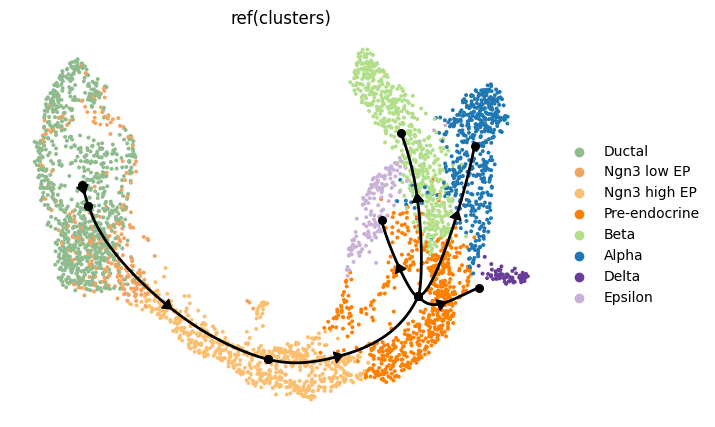

In [10]:
fadata = cafe.data.read_pancrease()
del fadata.uns["neighbors"] # velocity neighbor info error, need recalculate
cafe.plot.plot_trajectory(fadata)

DEBUG    |- load conda backend                                                                                                                                                                          
DEBUG    |--- Conda environment 'cfe' is available: Python 3.10.15                                                                                                                                      
DEBUG    |- Loaded function 'graph_mst': <function graph_mst at 0x771fd8d88ee0>                                                                                                                         
INFO     |- method backend loaded: CondaBackend: graph_mst in conda env 'cfe'                                                                                                                           
DEBUG    |- set new log file: .cafe/pancreas/log/graph_mst.log                                                                                                                                      

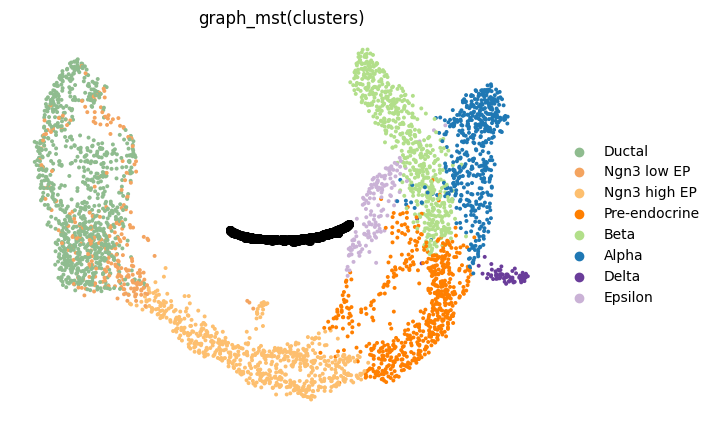

In [11]:
method2parameters = {
    # velocity
    # "velocity_mst": {}, # ok
    # "scvelo": {}, # ok
    # "dynamo": {}, # ok
    # "velovi": {}, # ok
    # "pyrovelocity": {}, # ok
    # "veloae": {},
    # "celldancer": {
    #     "velocity_kwargs": {"max_epoches": 200},
    #     "compute_cell_velocity_kwargs": {"projection_neighbor_size": 100},
    # }, # OK
    # "unitvelo": {},  # ok
    
    # linear, pseudotime
    # "comp1": {}, # ok
    # "palantir": {}, # ok
    # "cytotrace2": {}, # ok
    # "sctc": {}, # ok
    
    # probability
    # "state_comp": {}, # ok
    
    # cluster
    # "cluster_mst": {}, # ok
    # "stavia": {}, # ok
    
    # projection
    # "projection_mst": {}, # ok
    
    # graph
    "graph_mst": {}, # ok
    
    # lineage
    # state comp
    # "cellrank": {}, # ok
    
    # TODO: time
    # moscot
}

for method_name, parameters in method2parameters.items():
    parameters["repreprocess"] = True
    parameters["benchmark_resource"] = True  # record resource usage
    method = cafe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata, parameters=parameters, id=method_name)
    # save in time, without waiting for all methods to finish, waypoint are not calculated
    fadata.write_trajectory_dict(model_name_list=[fadata.model_name])
    cafe.plot.plot_trajectory(fadata, save=True)
    

DEBUG    |- extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                                                 
DEBUG    |- plot_trajectory for model_name:'ref', color:'clusters'                                                                                                                                      
DEBUG    |- 'ref' is not a valid random_time_string, don't need parse                                                                                                                                   
DEBUG    |- plot_trajectory for model_name:'ref', color:'milestone'                                                                                                                                     
DEBUG    |- 'ref' is not a valid random_time_string, don't need parse                                                                                                                               

array([[<Axes: title={'center': 'ref(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>,
        <Axes: title={'center': 'graph_mst(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>],
       [<Axes: title={'center': 'ref(milestone)'}, xlabel='X_umap1', ylabel='X_umap2'>,
        <Axes: title={'center': 'graph_mst(milestone)'}, xlabel='X_umap1', ylabel='X_umap2'>]],
      dtype=object)

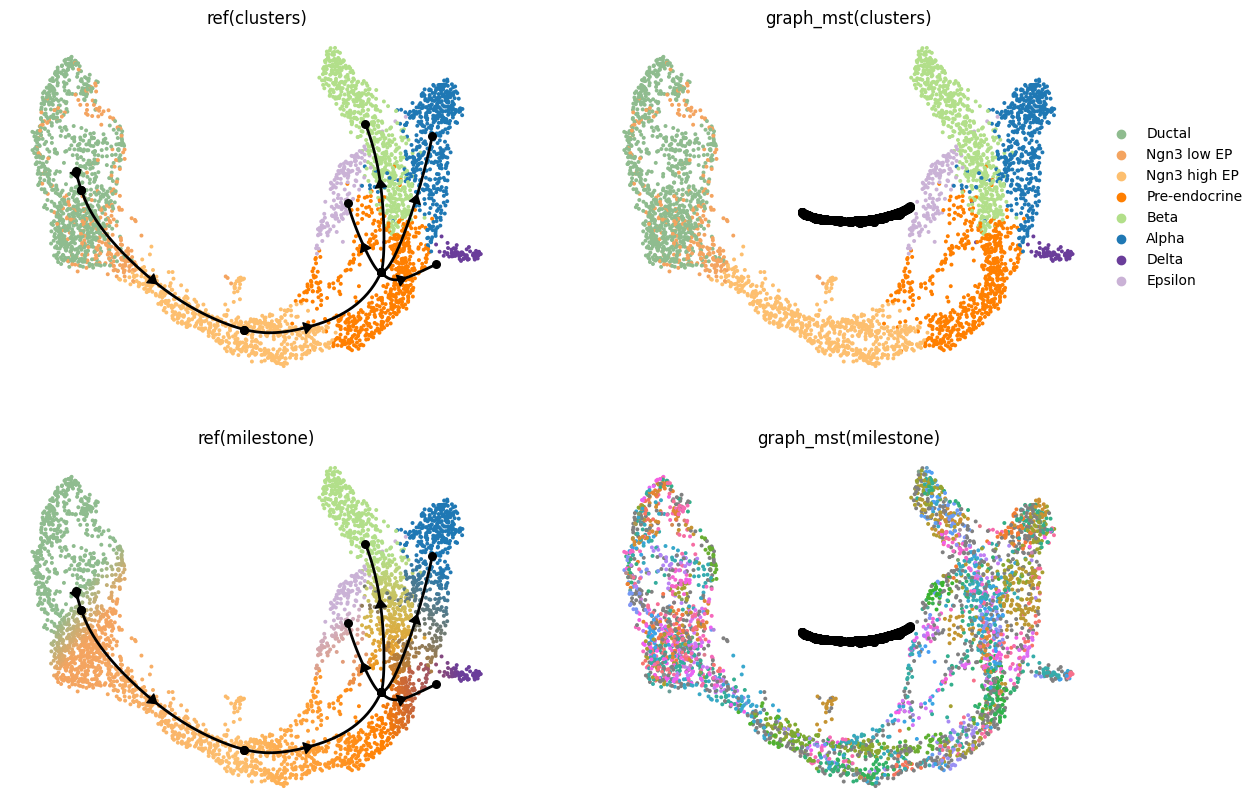

In [12]:
model_name_list = fadata.get_all_model_name(parse=False)
color_list = ["clusters", "milestone"]

cafe.plot.plot_trajectory(fadata, model_name=model_name_list, color=color_list)

In [13]:
fadata.write_trajectory_dict() 

DEBUG    |- write trajectory 'ref' to '.cafe/pancreas/trajectory_history/ref.pkl'                                                                                                                       
DEBUG    |- write trajectory 'graph_mst' to '.cafe/pancreas/trajectory_history/graph_mst.pkl'                                                                                                           
